# Feedback Simulator

In [2]:
import os
import numpy as np
import pandas as pd
from nilearn.maskers import NiftiMasker

In [3]:
# Settings
data_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE'
fmriprep_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/fmriprep23/fmriprep'
nilearn_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/nilearn-glm'
output_dir = '/Users/alexandresayal/sftp/DATAPOOL/VPMB/BIDS-VPMB-SPE/derivatives/feedbackSimulator'

In [106]:
subject_label = 'sub-01'
task_label = 'task-AA_acq-0500_run-1'
tr = 0.5
fmri_img = os.path.join(fmriprep_dir, subject_label, 'func', f'{subject_label}_{task_label}_space-MNI152NLin2009cAsym_res-2_desc-preproc_bold.nii.gz')
mask_img = os.path.join(nilearn_dir,'group','mask_hMT.nii.gz')
confounds_file = os.path.join(fmriprep_dir, subject_label, 'func', f'{subject_label}_{task_label}_desc-confounds_timeseries.tsv')
events_file = os.path.join(data_dir, subject_label, 'func', f'{subject_label}_{task_label}_events.tsv')
hrf_delay = 4 # in seconds

In [11]:
# load confounds
confounds = pd.read_csv(confounds_file, 
                        sep='\t', 
                        usecols = ['csf','csf_derivative1','csf_power2','csf_derivative1_power2',
                                    'white_matter', 'white_matter_derivative1', 'white_matter_power2', 'white_matter_derivative1_power2',
                                    'trans_x', 'trans_x_derivative1', 'trans_x_power2', 'trans_x_derivative1_power2',
                                    'trans_y', 'trans_y_derivative1', 'trans_y_power2', 'trans_y_derivative1_power2',
                                    'trans_z', 'trans_z_derivative1', 'trans_z_power2', 'trans_z_derivative1_power2',
                                    'rot_x', 'rot_x_derivative1', 'rot_x_power2', 'rot_x_derivative1_power2',
                                    'rot_y', 'rot_y_derivative1', 'rot_y_power2', 'rot_y_derivative1_power2',
                                    'rot_z', 'rot_z_derivative1', 'rot_z_power2', 'rot_z_derivative1_power2',
                                    'framewise_displacement']
                        )

confounds.fillna(0, inplace=True)
confounds

,csf,csf_derivative1,csf_derivative1_power2,csf_power2,white_matter,white_matter_derivative1,white_matter_derivative1_power2,white_matter_power2,framewise_displacement,trans_x,...,rot_x_power2,rot_x_derivative1_power2,rot_y,rot_y_derivative1,rot_y_derivative1_power2,rot_y_power2,rot_z,rot_z_derivative1,rot_z_derivative1_power2,rot_z_power2
0,13814.515756,0.000000,0.000000,1.908408e+08,8952.636986,0.000000,0.000000,8.014971e+07,0.000000,0.030010,...,7.975276e-47,0.000000e+00,-0.000360,0.000000,0.000000e+00,1.298420e-07,-0.000324,0.000000,0.000000e+00,1.046807e-07
1,13667.936096,-146.579660,21485.596608,1.868125e+08,8949.110587,-3.526399,12.435491,8.008658e+07,0.030076,0.016822,...,5.793204e-09,5.793204e-09,-0.000239,0.000121,1.474913e-08,5.706843e-08,-0.000276,0.000047,2.223405e-09,7.639198e-08
2,13546.491157,-121.444939,14748.873241,1.835074e+08,8962.276353,13.165766,173.337401,8.032240e+07,0.098996,0.017419,...,1.898092e-07,1.292819e-07,-0.000297,-0.000058,3.353916e-09,8.809202e-08,-0.000242,0.000035,1.215220e-09,5.833722e-08
3,13502.779838,-43.711319,1910.679382,1.823251e+08,8974.504222,12.227870,149.520798,8.054173e+07,0.179729,0.019784,...,1.747049e-06,7.851537e-07,-0.000074,0.000223,4.951982e-08,5.516404e-09,-0.000440,-0.000198,3.920479e-08,1.931893e-07
4,13413.051317,-89.728521,8051.207439,1.799099e+08,8984.134433,9.630211,92.740956,8.071467e+07,0.123331,0.023938,...,8.148059e-07,1.756398e-07,-0.000150,-0.000075,5.667756e-09,2.236730e-08,-0.000240,0.000200,3.988089e-08,5.751891e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,13195.731622,-168.510665,28395.844275,1.741273e+08,8927.058830,-45.702237,2088.694496,7.969238e+07,0.274980,0.168657,...,5.833626e-06,1.117186e-06,-0.002012,-0.000794,6.298010e-07,4.046333e-06,0.004849,0.000674,4.539525e-07,2.351154e-05
776,13087.134338,-108.597283,11793.369971,1.712731e+08,8920.958944,-6.099886,37.208607,7.958351e+07,0.221782,0.197662,...,1.352034e-06,1.568806e-06,-0.002379,-0.000368,1.352768e-07,5.661306e-06,0.005526,0.000677,4.578552e-07,3.053137e-05
777,13142.324216,55.189877,3045.922575,1.727207e+08,8922.316656,1.357712,1.843382,7.960773e+07,0.337164,0.260017,...,5.181086e-06,1.239726e-06,-0.003135,-0.000755,5.707349e-07,9.827096e-06,0.006348,0.000822,6.761280e-07,4.029444e-05
778,13128.908133,-13.416083,179.991278,1.723682e+08,8917.553687,-4.762969,22.685873,7.952276e+07,0.182132,0.256397,...,9.529939e-06,6.574939e-07,-0.003056,0.000079,6.193690e-09,9.339869e-06,0.005695,-0.000653,4.266180e-07,3.242881e-05


In [60]:
masker = NiftiMasker(labels_img=mask_img, standardize=False)

In [61]:
time_series = masker.fit_transform(fmri_img,
                                   confounds=confounds)

/opt/anaconda3/envs/vpmb-tr/lib/python3.11/site-packages/joblib/memory.py:349: FutureWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  return self.func(*args, **kwargs)


In [151]:
time_series.shape

(780, 713849)

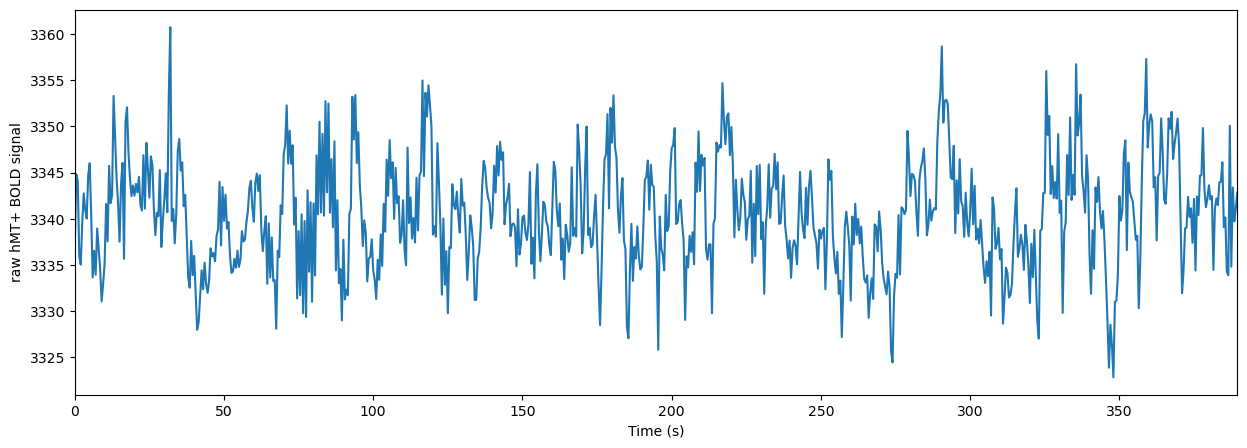

In [153]:
time_series_mean = time_series.mean(axis=1)

# create time vector based on TR
time_vector = np.arange(0, time_series.shape[0]*tr, tr)

# plot roi_mean signal as a function of time
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
plt.plot(time_vector,time_series_mean)
plt.xlim(0, time_vector[-1])
plt.xlabel('Time (s)')
plt.ylabel('raw hMT+ BOLD signal')

plt.show()


In [154]:
# Load events file
events = pd.read_csv(events_file, sep='\t')
events

,onset,duration,trial_type
0,0,15,Discard
1,15,30,Static
2,45,120,Ambiguous
3,165,15,MAE
4,180,30,Static
5,210,120,Ambiguous
6,330,15,MAE
7,345,30,Static
8,375,15,Discard


In [155]:
# Fetch the points of 'Static' events (to normalize the time_series)
static_events = events[events['trial_type']=='Static']

# Get the time points of the static events - these start at the onset and last for duration
static_events_onsets = static_events['onset'].values
static_events_durations = static_events['duration'].values

# create vector with all the time points of the static events
static_events_indexes = np.array([])
for i in range(len(static_events_onsets)):
    static_events_indexes = np.append(static_events_indexes, np.arange(static_events_onsets[i]/tr, static_events_onsets[i]/tr+static_events_durations[i]/tr))

static_events_indexes = ( static_events_indexes - 1 + (hrf_delay/tr) ).astype(int)
static_events_indexes


array([ 37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,
        50,  51,  52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,
        63,  64,  65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,
        76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,
        89,  90,  91,  92,  93,  94,  95,  96, 367, 368, 369, 370, 371,
       372, 373, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384,
       385, 386, 387, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397,
       398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410,
       411, 412, 413, 414, 415, 416, 417, 418, 419, 420, 421, 422, 423,
       424, 425, 426, 697, 698, 699, 700, 701, 702, 703, 704, 705, 706,
       707, 708, 709, 710, 711, 712, 713, 714, 715, 716, 717, 718, 719,
       720, 721, 722, 723, 724, 725, 726, 727, 728, 729, 730, 731, 732,
       733, 734, 735, 736, 737, 738, 739, 740, 741, 742, 743, 744, 745,
       746, 747, 748, 749, 750, 751, 752, 753, 754, 755, 756])

In [156]:
# get mean of time series at static events
static_events_time_series_mean = time_series_mean[static_events_indexes].mean(axis=0)

static_events_time_series_mean


3340.8882

In [157]:
# normalize time series using the mean of the static events
time_series_norm = (time_series_mean - static_events_time_series_mean)/static_events_time_series_mean*100

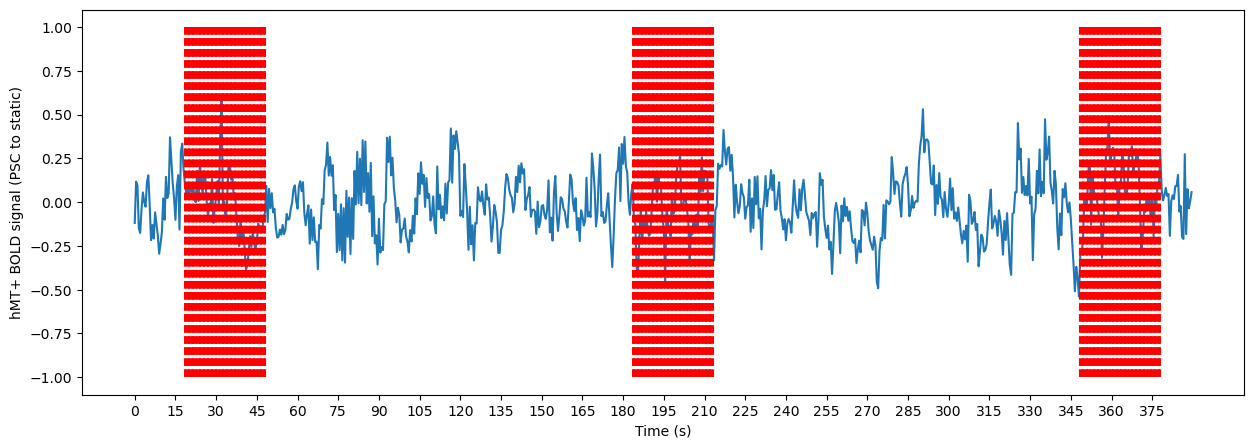

In [162]:
# plot roi_mean signal as a function of time
import matplotlib.pyplot as plt
plt.figure(figsize=(15,5))
plt.plot(time_series_norm)
#plt.xlim(0, time_vector[-1])
plt.xticks(np.arange(0, time_series.shape[0], 30), np.arange(0, time_series.shape[0]*tr, 30*tr).astype(int))
plt.xlabel('Time (s)')
plt.ylabel('hMT+ BOLD signal (PSC to static)')
plt.vlines(static_events_indexes, ymin=-1, ymax=1, color='r', linestyle='--')
plt.show()


In [163]:
# get the time points of the ambiguous blocks
ambiguous_events = events[events['trial_type']=='Ambiguous']
ambiguous_events_onsets = ambiguous_events['onset'].values
ambiguous_events_durations = ambiguous_events['duration'].values

# create matrix with all the time points of the ambiguous blocks, one per column
ambiguous_events_indexes = np.empty(((ambiguous_events_durations[0]/tr).astype(int), len(ambiguous_events_onsets)), int)

# convert times to indexes and add hemodynamic delay
for i in range(len(ambiguous_events_onsets)):
    ambiguous_events_indexes[:,i] = np.arange(ambiguous_events_onsets[i]/tr, ambiguous_events_onsets[i]/tr+ambiguous_events_durations[i]/tr)

ambiguous_events_indexes = ( ambiguous_events_indexes - 1 + (hrf_delay/tr) ).astype(int)
ambiguous_events_indexes

array([[ 97, 427],
       [ 98, 428],
       [ 99, 429],
       [100, 430],
       [101, 431],
       [102, 432],
       [103, 433],
       [104, 434],
       [105, 435],
       [106, 436],
       [107, 437],
       [108, 438],
       [109, 439],
       [110, 440],
       [111, 441],
       [112, 442],
       [113, 443],
       [114, 444],
       [115, 445],
       [116, 446],
       [117, 447],
       [118, 448],
       [119, 449],
       [120, 450],
       [121, 451],
       [122, 452],
       [123, 453],
       [124, 454],
       [125, 455],
       [126, 456],
       [127, 457],
       [128, 458],
       [129, 459],
       [130, 460],
       [131, 461],
       [132, 462],
       [133, 463],
       [134, 464],
       [135, 465],
       [136, 466],
       [137, 467],
       [138, 468],
       [139, 469],
       [140, 470],
       [141, 471],
       [142, 472],
       [143, 473],
       [144, 474],
       [145, 475],
       [146, 476],
       [147, 477],
       [148, 478],
       [149,

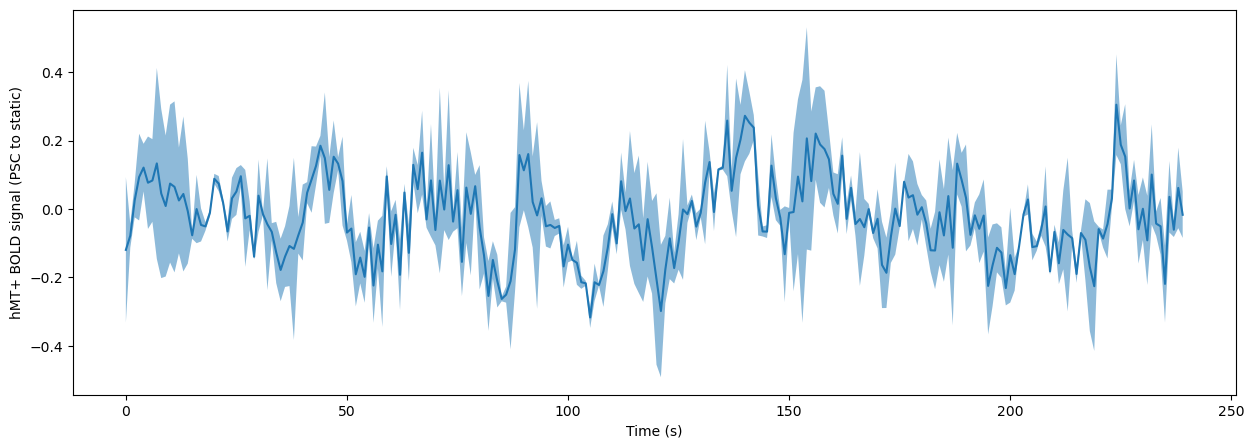

In [164]:
# plot the mean and std of the two ambiguous blocks
to_plot = time_series_norm[ambiguous_events_indexes].mean(axis=1)
to_plot_std = time_series_norm[ambiguous_events_indexes].std(axis=1)

plt.figure(figsize=(15,5))
plt.plot(to_plot)
plt.fill_between(np.arange(len(to_plot)), to_plot-to_plot_std, to_plot+to_plot_std, alpha=0.5)
plt.xlabel('Time (s)')
plt.ylabel('hMT+ BOLD signal (PSC to static)')
plt.show()
